# Лабораторная работа: Поиск частых наборов объектов с помощью алгоритма Apriori

github:

## 1. Формулировка задания
1. Разработать оптимизированную программу поиска частых наборов объектов алгоритмом Apriori с возможностью сортировки (по поддержке / лексикографически).
2. Провести серию экспериментов на транзакционном датасете `baskets.csv` при порогах поддержки: 1%, 3%, 5%, 10%, 15%.
3. Визуализировать зависимость быстродействия и структуры найденных наборов от порога поддержки.
4. Проанализировать результаты и сформировать отчет.

In [1]:
from collections import defaultdict
from itertools import combinations
import sys
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11


def load_dataset(file_path):
    transactions = []
    with open(file_path, "r", encoding="cp1251") as f:
        for line in f:
            items = (
                sys.intern(item.strip())
                for item in line.split(",")
                if item.strip()
            )
            t = frozenset(items)
            if t:
                transactions.append(t)
    return transactions


# Загружаем датасет
file_name = "baskets.csv"
transactions = load_dataset(file_name)

print(f"Успешно загружено транзакций: {len(transactions)}")
if transactions:
    print(f"Пример первой корзины: {list(transactions[0])}")

Успешно загружено транзакций: 7501
Пример первой корзины: ['зеленый виноград', 'авокадо', 'замороженный смузи', 'шпинат', 'лосось', 'низкокалорийный йогурт', 'батат', 'овощная смесь', 'мед', 'зеленый чай', 'минеральная вода', 'ягодный сок', 'миндаль', 'креветки', 'творог', 'оливковое масло', 'томатный сок', 'цельнозерновая мука', 'салат', 'энергетический напиток']


In [2]:
def apriori(transactions, min_support=0.05, sort_by="support"):
    n_trans = len(transactions)
    min_count = min_support * n_trans

    item_counts = defaultdict(int)
    for t in transactions:
        for item in t:
            item_counts[frozenset([item])] += 1

    current_L = {k: v for k, v in item_counts.items() if v >= min_count}
    all_frequent = dict(current_L)

    k = 2
    while current_L:
        prev_itemsets = list(current_L.keys())
        candidates = set()

        for i in range(len(prev_itemsets)):
            for j in range(i + 1, len(prev_itemsets)):
                union = prev_itemsets[i] | prev_itemsets[j]
                if len(union) == k:
                    if all(
                        frozenset(sub) in current_L
                        for sub in combinations(union, k - 1)
                    ):
                        candidates.add(union)

        if not candidates:
            break

        cand_counts = defaultdict(int)
        for t in transactions:
            for c in candidates:
                if c.issubset(t):
                    cand_counts[c] += 1

        current_L = {
            k_set: v for k_set, v in cand_counts.items() if v >= min_count
        }
        all_frequent.update(current_L)
        k += 1

    if not all_frequent:
        return pd.DataFrame(columns=["itemset", "support", "length"])

    df = pd.DataFrame(
        (
            (sorted(itemset), count / n_trans, len(itemset))
            for itemset, count in all_frequent.items()
        ),
        columns=["itemset", "support", "length"],
    )

    if sort_by == "support":
        df.sort_values(
            by=["support", "length"], ascending=[False, False], inplace=True
        )
    elif sort_by == "lexicographical":
        df.sort_values(
            by="itemset", key=lambda col: col.str.join(", "), inplace=True
        )

    return df.reset_index(drop=True)

In [3]:
thresholds = [0.01, 0.03, 0.05, 0.10, 0.15]

experiment_data = []
detailed_lengths = {}

for sup in thresholds:
    label = f"{int(sup*100)}%"
    print(f"Эксперимент для min_support = {label}...")

    start = time.time()
    res_df = apriori(transactions, min_support=sup, sort_by="support")
    exec_time = time.time() - start

    experiment_data.append(
        {
            "min_support": sup,
            "min_support_str": label,
            "total_itemsets": len(res_df),
            "time_sec": exec_time,
        }
    )

    detailed_lengths[label] = res_df["length"].value_counts().to_dict()

df_experiments = pd.DataFrame(experiment_data)
df_experiments

Эксперимент для min_support = 1%...
Эксперимент для min_support = 3%...
Эксперимент для min_support = 5%...
Эксперимент для min_support = 10%...
Эксперимент для min_support = 15%...


,min_support,min_support_str,total_itemsets,time_sec
0,0.01,1%,261,1.159349
1,0.03,3%,55,0.255840
2,0.05,5%,28,0.102498
3,0.10,10%,7,0.013265
4,0.15,15%,5,0.010594


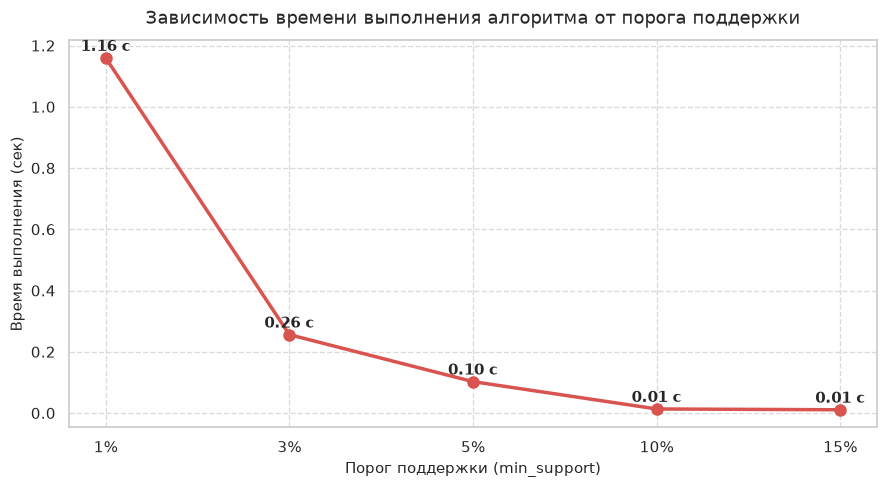

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(
    df_experiments["min_support_str"],
    df_experiments["time_sec"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#d9534f",
)

plt.title(
    "Зависимость времени выполнения алгоритма от порога поддержки",
    fontsize=13,
    pad=12,
)
plt.xlabel("Порог поддержки (min_support)", fontsize=11)
plt.ylabel("Время выполнения (сек)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)

for _, row in df_experiments.iterrows():
    plt.text(
        row["min_support_str"],
        row["time_sec"] + (max(df_experiments["time_sec"]) * 0.02),
        f"{row['time_sec']:.2f} с",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

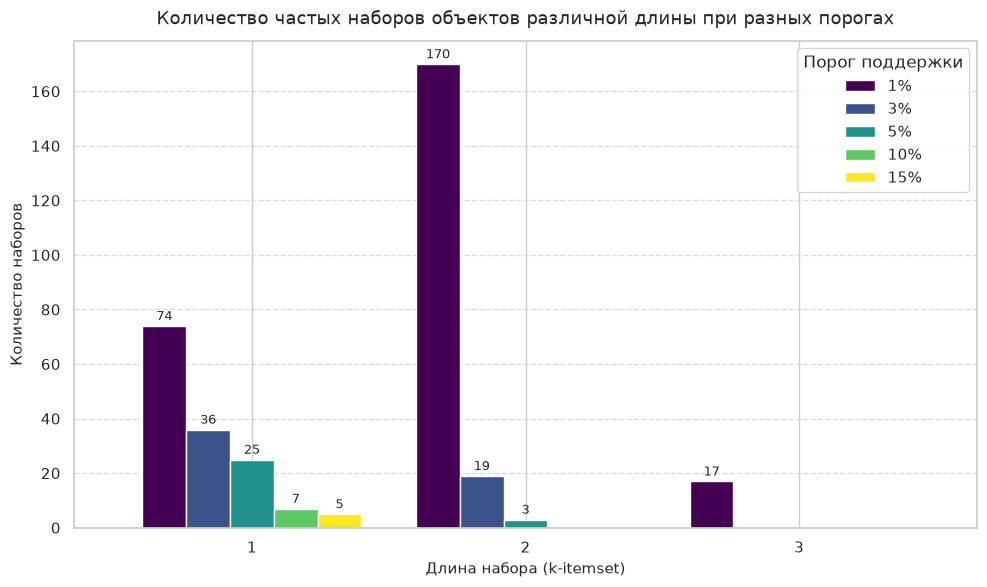

In [5]:
df_len_chart = (
    pd.DataFrame(detailed_lengths).fillna(0).astype(int).sort_index()
)
df_len_chart.index.name = "Длина набора (k-itemset)"

ax = df_len_chart.plot(
    kind="bar", figsize=(10, 6), colormap="viridis", width=0.8
)

plt.title(
    "Количество частых наборов объектов различной длины при разных порогах",
    fontsize=13,
    pad=12,
)
plt.xlabel("Длина набора (k-itemset)", fontsize=11)
plt.ylabel("Количество наборов", fontsize=11)
plt.xticks(rotation=0)
plt.legend(title="Порог поддержки")
plt.grid(axis="y", linestyle="--", alpha=0.7)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 2),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

## 4. Пояснения и анализ полученных результатов

### 1. Быстродействие алгоритма:
- Наблюдается нелинейное (близкое к экспоненциальному) увеличение времени расчета при снижении порога поддержки с 15% до 1%.
- Это объясняется комбинаторным взрывом: при малом значении порога `min_support` отсекается меньше кандидатов на этапе $L_1$ и $L_2$, из-за чего алгоритм вынужден проверять на порядок больше комбинаций подмножеств на шагах $k \ge 2$.

### 2. Структура найденных частых наборов:
- При высоких порогах поддержки (10% и 15%) обнаруживаются преимущественно единичные товары ($k=1$), являющиеся базовыми товарами повышенного спроса (хлеб, минеральная вода, яйца). Наборов длины $k \ge 2$ практически не формируется.
- При пороге 1% формируется значительное число наборов длины 2 и 3, что позволяет строить комплексные ассоциативные правила для рекомендательных систем и маркетинга.